### Sub - Data Understanding
 - We will investigate and understand the sub-data that we did from previous notebook as we took a subset from the dataset ( current from 2023 - 2026)
 - We will use as reference **Blueprints for Text Analytics using python**
 - We will first get an overview of the Data with Pandas
    - Calculate summary statistics
    - Check for missing values
    - Plot distributions of intersting attributes ('Costumer narrative complaint')

In [6]:
#Importing libraries
import os
import pandas as pd
import regex as re
import nltk
from collections import Counter
 #tokenization
nltk.download('punkt')
nltk.download('punkt_tab')
#Tokenize sentences
from nltk.tokenize import sent_tokenize, word_tokenize
#SpaCy
!pip install textacy

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.9/70.9 kB 3.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.4/360.4 kB 35.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 78.7 MB/s eta 0:00:00
  Created wheel for floret: filename=floret-0.10.5-cp313-cp313-linux_x86_64.whl size=5045942 sha256=3ac99c31444ae497827378d2ebf13cd875facfa852a5799450599e7e8c38251e
  Stored in directory: /root/.cache/pip/wheels/20/4f/28/fcfb0b1b03c6de8d45ead19cc004f927e9e9f6c28f2c50b1a9
Successfully built floret


In [7]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [8]:
df = pd.read_csv("/content/drive/My Drive/DATA/cleaned_data.csv")
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313445 entries, 0 to 2313444
Data columns (total 17 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Unnamed: 0                    int64 
 1   Date received                 object
 2   Product                       object
 3   Sub-product                   object
 4   Issue                         object
 5   Sub-issue                     object
 6   Consumer complaint narrative  object
 7   Company public response       object
 8   Company                       object
 9   State                         object
 10  ZIP code                      object
 11  Tags                          object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Complaint ID                  int64 
dtypes: int64(2), object(15)
memory usage: 300.1+ MB
None


# Chunking pipeline
chunk_size = 50000
batch_no = 1
path = '/content/drive/My Drive/DATA/chunks/'
for chunk in pd.read_csv("/content/drive/My Drive/DATA/cleaned_data.csv",chunksize=chunk_size):
  chunk.to_csv(path + 'batch'+str(batch_no)+'.csv',index=False)
  batch_no += 1

In [9]:
df['length'] = df['Consumer complaint narrative'].str.len()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,2313445.0,1.156722e+06,6.678342e+05,0.0,578361.0,1156722.0,1735083.0,2313444.0
Complaint ID,2313445.0,1.236498e+07,3.359282e+06,7451721.0,9565619.0,11855457.0,14632606.0,24635023.0
length,2313445.0,1.016408e+03,1.308621e+03,10.0,331.0,662.0,1217.0,35984.0


In [10]:
df.isna().sum()

,0
Unnamed: 0,0
Date received,0
Product,0
Sub-product,0
Issue,0
Sub-issue,117957
Consumer complaint narrative,0
Company public response,1053091
Company,0
State,8191


<Axes: >

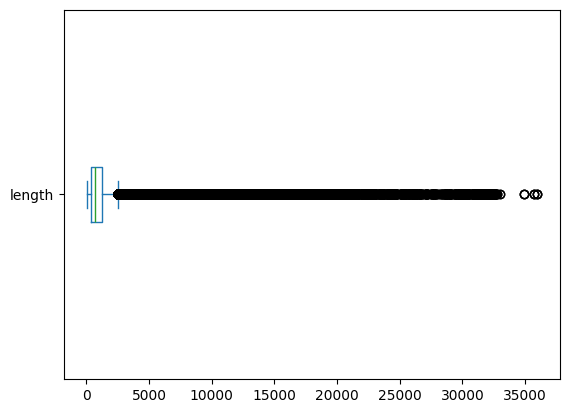

In [11]:
df['length'].plot(kind='box', vert=False)

<Axes: ylabel='Frequency'>

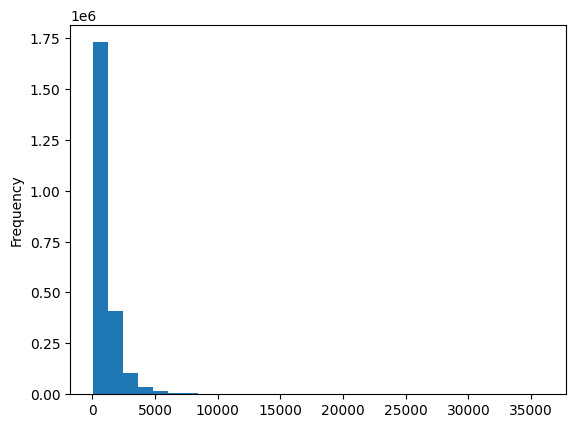

In [12]:
df['length'].plot(kind='hist',bins=30)

## Data Preprocessing Pipeline
### Data Cleaning
**Input** : **Source Text**
- Identify Noise
- Noise Removal
- Character normalization
- Data masking

**Output** : **Clean Text**
### Linguitic Processing
**Input** : **Clean Text**
 - Tokenization
 - Pos tagging
 - Lemmatization
 - Named-entity recognition (NER)

**Output** : **Prepared text**

In [13]:
pd.set_option('display.max_colwidth',None)
df['Consumer complaint narrative'].head(5)

,Consumer complaint narrative
0,"Subject : Dispute of XXXX XXXX XXXXXXXX and XXXX XXXX XXXX Account Under FCRA To Whom It May Concern, I am writing to formally dispute the collection account reported on my Experian credit report by XXXX XXXX XXXX and XXXX XXXX XXXX. According to the Nationwide Multistate Licensing System ( NMLS ), this company is not licensed to collect debts in the state of ARIZONA. As such, this accounts reporting is inaccurate and should be permanently removed from my credit report. Under the Fair Credit Reporting Act ( FCRA ), specifically 15 USC 1681e ( b ), Experian is required to follow reasonable procedures to ensure maximum possible accuracy in consumer reports. Reporting a collection account from an entity not authorized to operate in ARIZONA constitutes a violation of this standard. Furthermore, under 15 USC 1681i ( a ) ( 1 ), I am entitled to dispute inaccurate information, and Experian is obligated to investigate and correct or delete unverifiable data. Actions Requested Proof of Licensing : Provide verifiable proof that XXXX XXXX XXXXXXXX, and XXXX XXXX XXXX is licensed to collect debts in ARIZONA. Remove the Inaccurate Entry : If such proof can not be provided, permanently delete this collection account from my credit report. Provide Written Confirmation : Send me written confirmation of the accounts removal and an updated copy of my credit report reflecting the correction. Enclosed are the following documents for your reference : A copy of my credit report highlighting the disputed XXXX XXXX XXXX XXXX XXXX XXXX accounts. Documentation from the Nationwide Multistate Licensing System showing that XXXX XXXX XXXX, AND XXXX XXXX XXXX XXXX is not licensed to collect in ARIZONA. I request that you complete your investigation and provide a response within the 30-day timeframe required under the FCRA. Should you fail to address this matter appropriately, I will escalate my concerns by filing complaints with the Consumer Financial Protection Bureau ( CFPB ), the Federal Trade Commission ( FTC ), and the California Attorney Generals office. Thank you for your prompt attention to this matter. Sincerely, XXXX XXXX"
1,"I am currently reviewing my Experian Credit report and there are addresses reporting on my credit report that are not mine. Below is a list of the addresses that I would like to have permanently deleted : XXXX. XXXX XXXX XXXX XXXX XXXX XXXX XXXX, AZ XXXX XXXX. XXXX XXXX XXXX XXXX XXXX XXXX XXXX, TX XXXX"
2,"Subject : Dispute of Debt and Refusal to Pay To Whom It May Concern, I am writing in response to your attempt to collect a debt allegedly owed by me. Pursuant to my rights under the Fair Credit Reporting Act ( FCRA ) and the Fair Debt Collection Practices Act ( FDCPA ), specifically 15 U.S.C. 1692c ( c ), I am formally notifying you that I refuse to pay this debt and dispute its validity. Under 15 U.S.C. 1692c ( c ), once a consumer notifies a debt collector in writing that they refuse to pay a debt, the debt collector must cease all further communication except to confirm the termination of collection efforts or to notify the consumer of specific legal remedies. XXXX. XXXX XXXX Acct. No. : XXXX Additionally, under the FCRA and FDCPA, I request the following : Validation of Debt : If you believe this debt is valid, provide complete documentation to prove its legitimacy, including the original creditor, account details, and proof that this debt is collectible under applicable laws. Immediate Cessation of Reporting : If you can not validate this debt or establish its legitimacy, you must cease reporting it to any credit reporting agencies, including Experian, XXXX, and XXXX, as an unverified debt violates the FCRA. Notification of Resolution : Confirm in writing that this matter has been resolved and that no further collection actions will be taken. Any further attempts to collect this disputed debt without proper validation will be considered a violation of my rights under federal law and ma

#Character normalization
!pip install textacy
import textacy.preprocessing as tprep
def normalize(text):
    text = tprep.normalize.hyphenated_words(text)
    text = tprep.normalize.quotation_marks(text)
    text = tprep.remove.accents(text)
    return text

from nltk.tokenize import sent_tokenize, word_tokenize
nltk.download('punkt')
nltk.download('punkt_tab')
file_count = sum(1 for entry in os.scandir(path) if entry.is_file())
processed_path = path + 'Processed/'
for i in range(1,file_count+1,1):
  file_name = 'batch' + str(i) + '.csv'
  full_path = path + file_name
  df = pd.read_csv(full_path)
  df['Clean_text'] = df['Consumer complaint narrative'].apply(normalize)
  df['Sentence_tokenizers'] = df['Clean_text'].apply(sent_tokenize)
  df['Word_tokenizers'] = df['Clean_text'].apply(word_tokenize)
  df.to_csv(processed_path + 'batch'+str(i)+'.csv',index=False)

### As NTLK took a lot of time -> spaCy

In [14]:
import spacy
nlp = spacy.load('en_core_web_sm')

In [15]:
nlp.pipeline

[('tok2vec', <spacy.pipeline.tok2vec.Tok2Vec at 0x7a62b00d0f50>),
 ('tagger', <spacy.pipeline.tagger.Tagger at 0x7a62b00d1190>),
 ('parser', <spacy.pipeline.dep_parser.DependencyParser at 0x7a62b019f990>),
 ('attribute_ruler',
  <spacy.pipeline.attributeruler.AttributeRuler at 0x7a62a5f12c90>),
 ('lemmatizer',
  <spacy.lang.en.lemmatizer.EnglishLemmatizer at 0x7a62a5f13b50>),
 ('ner', <spacy.pipeline.ner.EntityRecognizer at 0x7a62b019f610>)]

In [16]:
if spacy.prefer_gpu():
  print("Working on GPU.")
else:
  print("No GPU found , working on CPU.")

Working on GPU.


In [33]:
'''
Functions that are going to be used in next pipeline:
 - Lemmatization
 - Noun phrases extraction
 - Named Entity Relations : NER
'''
# Lemmas
import textacy

def extract_lemmas(doc, **kwargs):
  return [t.lemma_ for t in textacy.extract.words(doc, **kwargs)]

# Noun Phrases
def extract_noun_phrases(doc, preceding_pos=['NOUN'], sep='_'):
  patterns = []
  for pos in preceding_pos:
    patterns.append(f"POS:{pos} POS:NOUN:+")
  spans = textacy.extract.matches.token_matches(doc, patterns=patterns)
  return [sep.join(t.lemma_ for t in s) for s in spans]

# NER
def extract_entities(doc, include_types=None, sep='_'):
  ents = textacy.extract.entities(
      doc,
      include_types=include_types,
      exclude_types=None,
      drop_determiners=True,
      min_freq=1
  )
  return [sep.join(t.lemma_ for t in e) + '/' + e.label_ for e in ents]

In [34]:
def extract_nlp(doc):
  return {
      'lemmas' : extract_lemmas(doc,exclude_pos=['PART','PUNCT'],filter_stops=False),
      'adj_verbs' : extract_lemmas(doc,include_pos =['ADJ','VERB'] ),
      'nouns' : extract_lemmas(doc,include_pos=  ['NOUN','PROPN']),
      'noun_phrases' : extract_noun_phrases(doc,['NOUN']),
      'adj_noun_phrases': extract_noun_phrases(doc,['ADJ']),
      'entities':extract_entities(doc,['PERSON','ORG','GPE','LOC'])
  }

In [ ]:
batch_size = 50
# let's define the columns
nlp_columns = list(extract_nlp(nlp.make_doc('')).keys())
for col in nlp_columns:
  df[col]=None
for i in range(0,len(df),batch_size):
  docs = nlp.pipe(df['Consumer complaint narrative'][i:i+batch_size])
  for j,doc in enumerate(docs):
    for col,values in extract_nlp(doc).items():
      df.at[df.index[i+j], col] = values